In [674]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.signal import find_peaks
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# Filter out the specific UserWarning from openpyxl
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")


In [675]:
assets = ['HDB', 'MBB', 'TCB', 'VCB', 'VPB']
df = pd.read_excel(f'Simplize_HDB_PriceHistory_20260222.xlsx', skiprows = 6, header = None).iloc[:-7,[0]]
df.columns = ['date']
df.set_index('date', inplace = True)
for a in assets:
    close_df = pd.read_excel(f'Simplize_{a}_PriceHistory_20260222.xlsx', skiprows = 6, header = None).iloc[:-7,[0,4]]
    close_col = f'close_{a}'
    close_df.columns = ['date', close_col]
    close_df.set_index('date', inplace = True )
    df = df.merge(close_df, left_index = True, right_index = True)

In [676]:
df = df[::-1] # reverse row order
df.index = pd.to_datetime(df.index, dayfirst=True) # index to datetime
df = df.iloc[-500: , :] # 3-year window

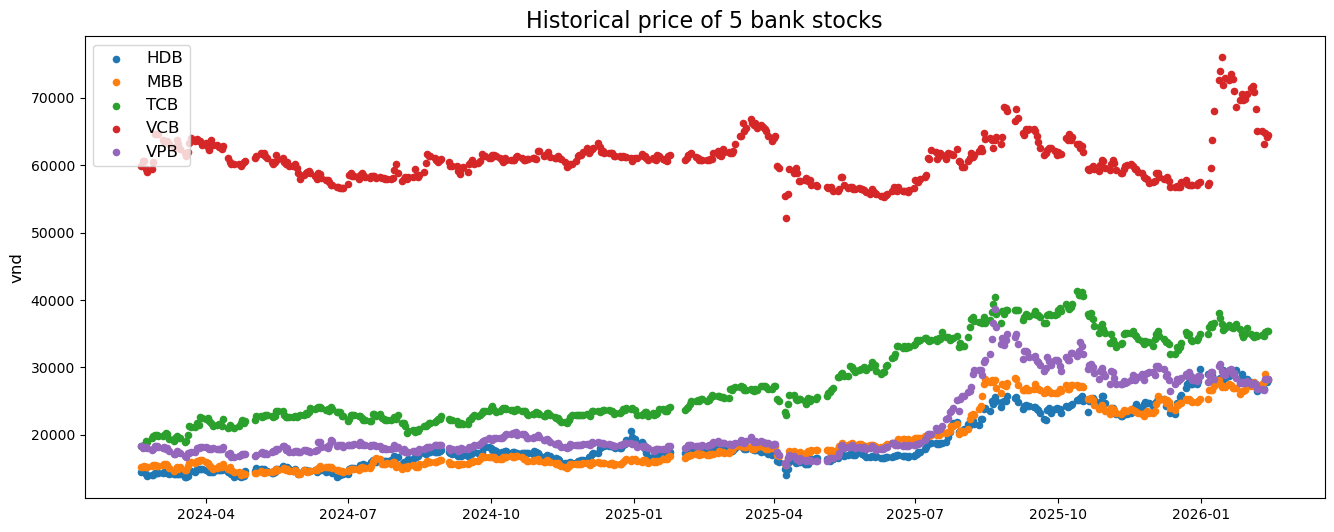

In [677]:
# Plot historical price movement

fig, ax = plt.subplots(figsize=(16, 6))
for a in assets:
    ax.scatter(x = df.index, y = df[f'close_{a}'], s = 20, label = a )
plt.legend(fontsize = 12, loc = 'upper left')
plt.title('Historical price of 5 bank stocks', fontsize = 16)
plt.ylabel('vnd', fontsize = 12)
plt.show()

In [678]:
# Plot returns and volatility

def return_vol_plot(expected_return, expected_vol, asset, title):
    x = np.arange(len(assets)) 
    width = 0.4
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, expected_return * 100, width, 
                    label='Expected Annual Returns', color='skyblue', edgecolor = 'black')
    ax.bar(x + width/2, expected_vol * 100, width, 
                    label='Expected Annual Volatility', color='salmon', edgecolor = 'black')
    ax.set_ylabel('Percentage (%)')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(assets)
    ax.legend()

    plt.show()

> ### 3 year data

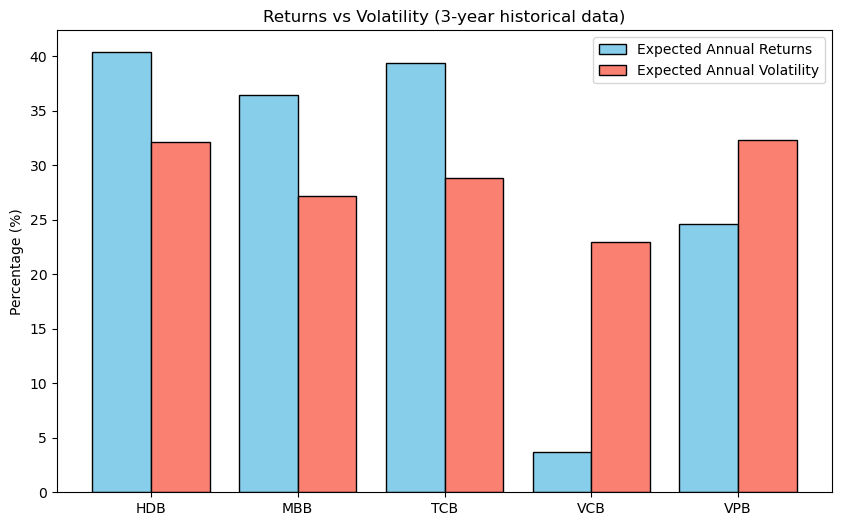

close_HDB    0.403598
close_MBB    0.364477
close_TCB    0.393510
close_VCB    0.037283
close_VPB    0.246191
dtype: float64
[0.32103957 0.27155406 0.28793453 0.22996113 0.32346023]


In [679]:
# Visualize different stocks' performance

mu = expected_returns.mean_historical_return(df)
S = risk_models.sample_cov(df)
return_vol_plot(mu.values, np.diag(np.sqrt(S)), assets, title = 'Returns vs Volatility (3-year historical data)')
print(mu)
print(np.diag(np.sqrt(S)))


====== PORTFIOLIO THAT MAXIMIZES SHARPE RATIO ====== 

OrderedDict({'close_HDB': 0.29323, 'close_MBB': 0.32417, 'close_TCB': 0.38259, 'close_VCB': 0.0, 'close_VPB': 0.0})
Expected annual return: 38.7%
Annual volatility: 24.9%
Sharpe Ratio: 1.55


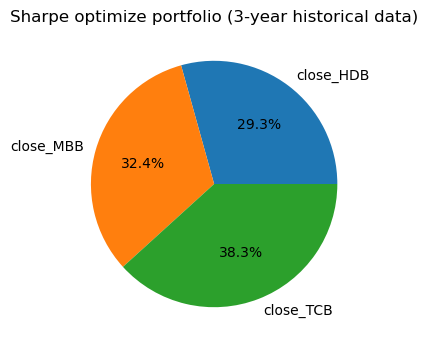

In [680]:
ef = EfficientFrontier(mu, S)
weights_max_sharpe = ef.max_sharpe()
weights_max_sharpe = ef.clean_weights()
print('====== PORTFIOLIO THAT MAXIMIZES SHARPE RATIO ======', '\n')
print(weights_max_sharpe)
ef.portfolio_performance(verbose = True)

non_zero_weights = {k: v for k, v in weights_max_sharpe.items() if v > 0}
plt.figure(figsize=(4, 4))
plt.pie(non_zero_weights.values(), labels = non_zero_weights.keys(), autopct='%1.1f%%')
plt.title("Sharpe optimize portfolio (3-year historical data)")
plt.show()

> ### 1 year data

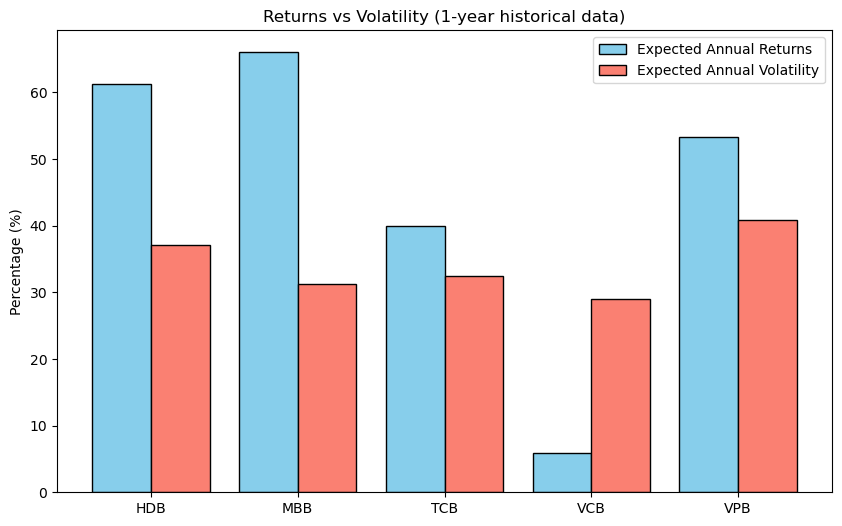

In [681]:
df_1_year = df.iloc[-250:,:]

mu = expected_returns.mean_historical_return(df_1_year)
S = risk_models.sample_cov(df_1_year)
return_vol_plot(mu.values, np.diag(np.sqrt(S)), assets, title = 'Returns vs Volatility (1-year historical data)')


====== PORTFIOLIO THAT MAXIMIZES SHARPE RATIO ====== 

OrderedDict({'close_HDB': 0.208, 'close_MBB': 0.792, 'close_TCB': 0.0, 'close_VCB': 0.0, 'close_VPB': 0.0})
Expected annual return: 65.0%
Annual volatility: 30.1%
Sharpe Ratio: 2.16


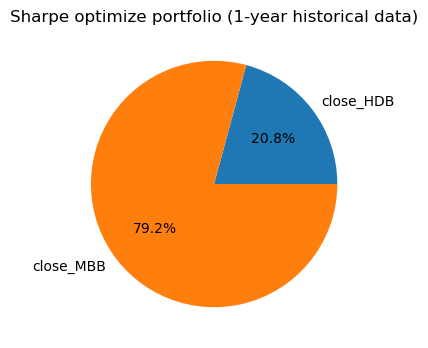

In [682]:
ef = EfficientFrontier(mu, S)
weights_max_sharpe = ef.max_sharpe()
weights_max_sharpe = ef.clean_weights()
print('====== PORTFIOLIO THAT MAXIMIZES SHARPE RATIO ======', '\n')
print(weights_max_sharpe)
ef.portfolio_performance(verbose = True)

non_zero_weights = {k: v for k, v in weights_max_sharpe.items() if v > 0}
plt.figure(figsize=(4, 4))
plt.pie(non_zero_weights.values(), labels = non_zero_weights.keys(), autopct='%1.1f%%')
plt.title("Sharpe optimize portfolio (1-year historical data)")
plt.show()

In [683]:
assets = ['HDB', 'MBB', 'TCB', 'VCB', 'VPB']
df = pd.read_excel(f'Simplize_HDB_PriceHistory_20260222.xlsx', skiprows = 6, header = None).iloc[:-7,[0]]
df.columns = ['date']
df.set_index('date', inplace = True)
for a in assets:
    close_df = pd.read_excel(f'Simplize_{a}_PriceHistory_20260222.xlsx', skiprows = 6, header = None).iloc[:-7,[0,4]]
    close_col = f'close_{a}'
    close_df.columns = ['date', close_col]
    close_df.set_index('date', inplace = True )
    df = df.merge(close_df, left_index = True, right_index = True)
df = df[::-1] # reverse row order
df.index = pd.to_datetime(df.index, dayfirst=True) # index to datetime

In [684]:
def analyze_seasonality(df_full, stock_name, min_prominence=0.5, min_distance=1):
    """
    Perform STL decomposition and visualize seasonality analysis for a given stock.
    
    Parameters:
    -----------
    df_full : pd.DataFrame
        Full dataframe with stock price data (must have 'date' as index)
    stock_name : str
        Name of the stock column (e.g., 'close_MBB', 'close_HDB')
    min_prominence : float, default=1.0
        Minimum prominence for peak detection (multiplied by std)
    min_distance : int, default=6
        Minimum distance between peaks in months
    """
    
    # Extract the stock column and resample to monthly frequency
    stock_series = df_full[stock_name]
    df_month = stock_series.resample('ME').last().reset_index()
    ts = df_month.set_index('date')[stock_name]
    
    # Perform STL decomposition
    stl = STL(ts, period=12)
    result = stl.fit()
    
    trend = result.trend
    seasonality = result.seasonal
    shock = result.resid
    
    # Find peaks in seasonality
    std = seasonality.std()
    MIN_PROMINENCE = std * min_prominence
    MIN_DISTANCE = min_distance
    
    high_peaks, high_props = find_peaks(
        seasonality,
        prominence=MIN_PROMINENCE,
        distance=MIN_DISTANCE
    )
    
    low_peaks, low_props = find_peaks(
        -seasonality,
        prominence=MIN_PROMINENCE,
        distance=MIN_DISTANCE
    )
    
    # Extract peak months
    seasonality_index = seasonality.index
    month_dict = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                  7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    high_peak_months = pd.to_datetime(seasonality_index[high_peaks]).month
    low_peak_months = pd.to_datetime(seasonality_index[low_peaks]).month
    
    # Count peaks per month
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    high_peak_counts = (
        pd.Series(high_peak_months)
        .map(month_dict)
        .value_counts()
        .reindex(month_order, fill_value=0)
    )
    
    low_peak_counts = (
        pd.Series(low_peak_months)
        .map(month_dict)
        .value_counts()
        .reindex(month_order, fill_value=0)
    )
    
    # Create matplotlib subplots
    fig, axes = plt.subplots(5, 1, figsize=(14, 14))
    fig.patch.set_facecolor('black')
    fig.suptitle(f'STL Decomposition - {stock_name}', color='white', fontsize=14, fontweight='bold')
    
    subtitles = ['Stock Price', 'Trend', 'Seasonality (12-month period)', 'Shock', 'Low and High Peaks by Month']
    
    # Price
    axes[0].plot(ts.index, ts, color='cyan', linewidth=1.5)
    axes[0].set_title(subtitles[0], color='white')
    axes[0].set_ylabel('Price', color='white')
    axes[0].set_facecolor('black')
    axes[0].grid(True, alpha=0.2, color='gray')
    
    # Trend
    axes[1].plot(ts.index, trend, color='lime', linewidth=1.5)
    axes[1].set_title(subtitles[1], color='white')
    axes[1].set_ylabel('Trend', color='white')
    axes[1].set_facecolor('black')
    axes[1].grid(True, alpha=0.2, color='gray')
    
    # Seasonality
    axes[2].plot(ts.index, seasonality, color='gray', linewidth=1.5)
    axes[2].scatter(seasonality_index[high_peaks], seasonality.iloc[high_peaks], color='green', s=100, marker='^', label='High Peaks')
    axes[2].scatter(seasonality_index[low_peaks], seasonality.iloc[low_peaks], color='red', s=100, marker='v', label='Low Peaks')
    axes[2].set_title(subtitles[2], color='white')
    axes[2].set_ylabel('Seasonal', color='white')
    axes[2].set_facecolor('black')
    axes[2].grid(True, alpha=0.2, color='gray')
    axes[2].legend(loc='upper left', facecolor='black', edgecolor='gray', labelcolor='white')
    
    # Shock
    axes[3].plot(ts.index, shock, color='deeppink', linewidth=1.5)
    axes[3].set_title(subtitles[3], color='white')
    axes[3].set_ylabel('Shock', color='white')
    axes[3].set_facecolor('black')
    axes[3].grid(True, alpha=0.2, color='gray')
    
    # Monthly low-high peak counts bar chart
    ax5 = axes[4]
    x_pos = np.arange(len(high_peak_counts))
    width = 0.35
    ax5.bar(x_pos - width/2, high_peak_counts.values, width, label='High Peaks', color='green', alpha=0.8)
    ax5.bar(x_pos + width/2, low_peak_counts.values, width, label='Low Peaks', color='red', alpha=0.8)
    ax5.set_title(subtitles[4], color='white')
    ax5.set_ylabel('Peak Counts', color='white')
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(high_peak_counts.index)
    ax5.set_facecolor('black')
    ax5.grid(True, alpha=0.2, color='gray', axis='y')
    ax5.legend(loc='upper left', facecolor='black', edgecolor='gray', labelcolor='white')
    
    # Style all axes
    for ax in axes:
        ax.tick_params(colors='white')
        for spine in ax.spines.values():
            spine.set_color('gray')
        for label in ax.get_xticklabels():
            label.set_color('white')
        for label in ax.get_yticklabels():
            label.set_color('white')
    
    plt.tight_layout()
    plt.show()

> ### Seasonality analysis

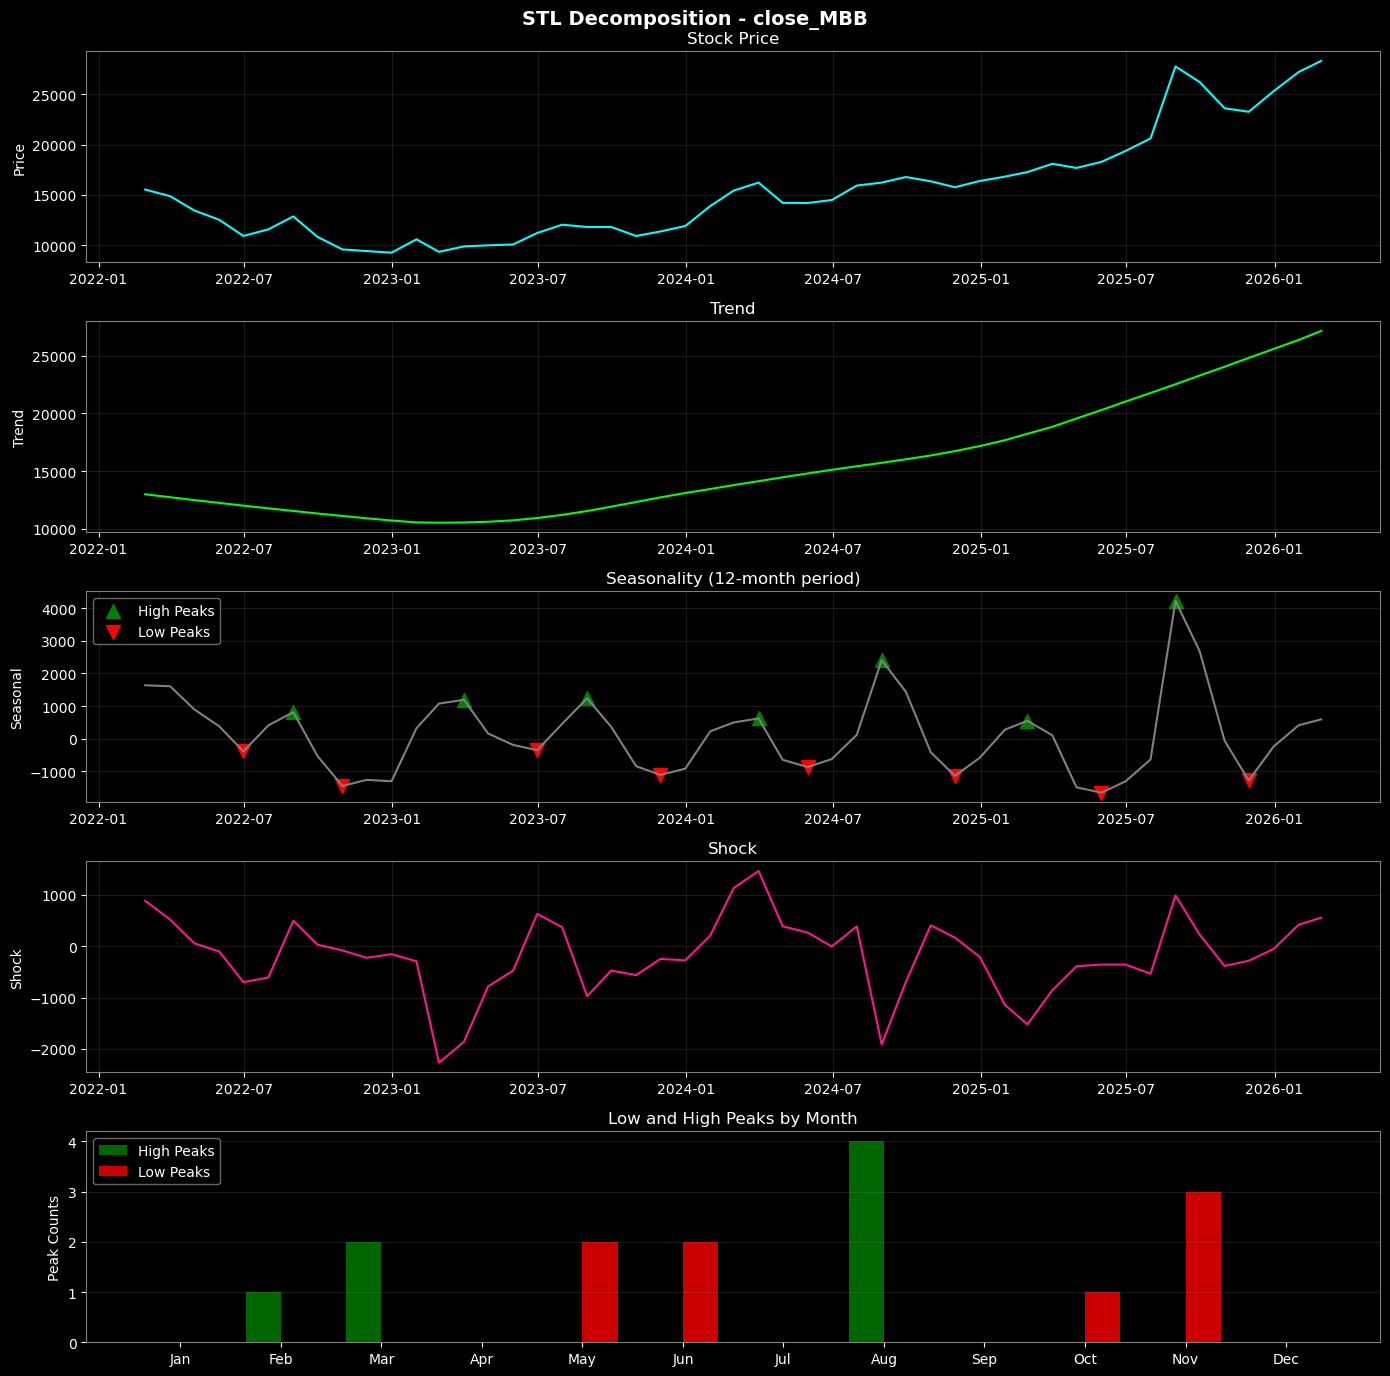

In [685]:
# Seasonality analysis for MBB
analyze_seasonality(df, 'close_MBB')

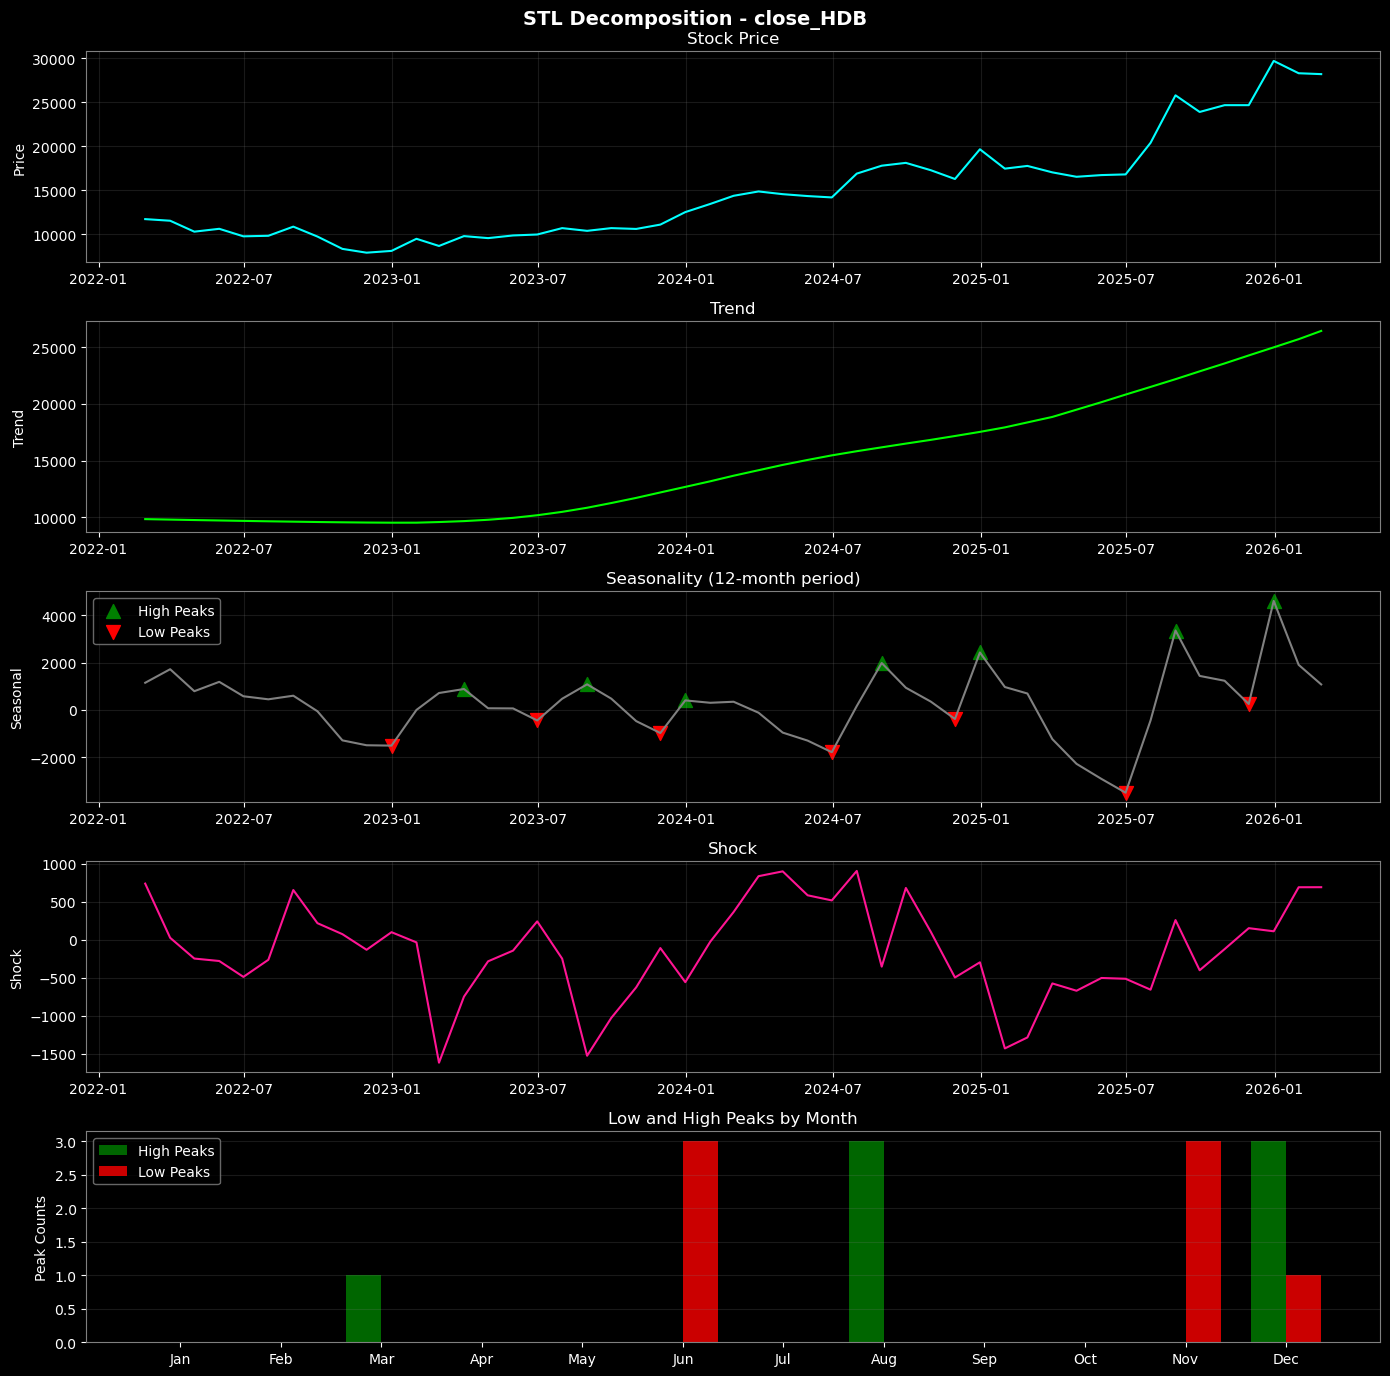

In [686]:
# Seasonality analysis for HDB
analyze_seasonality(df, 'close_HDB')

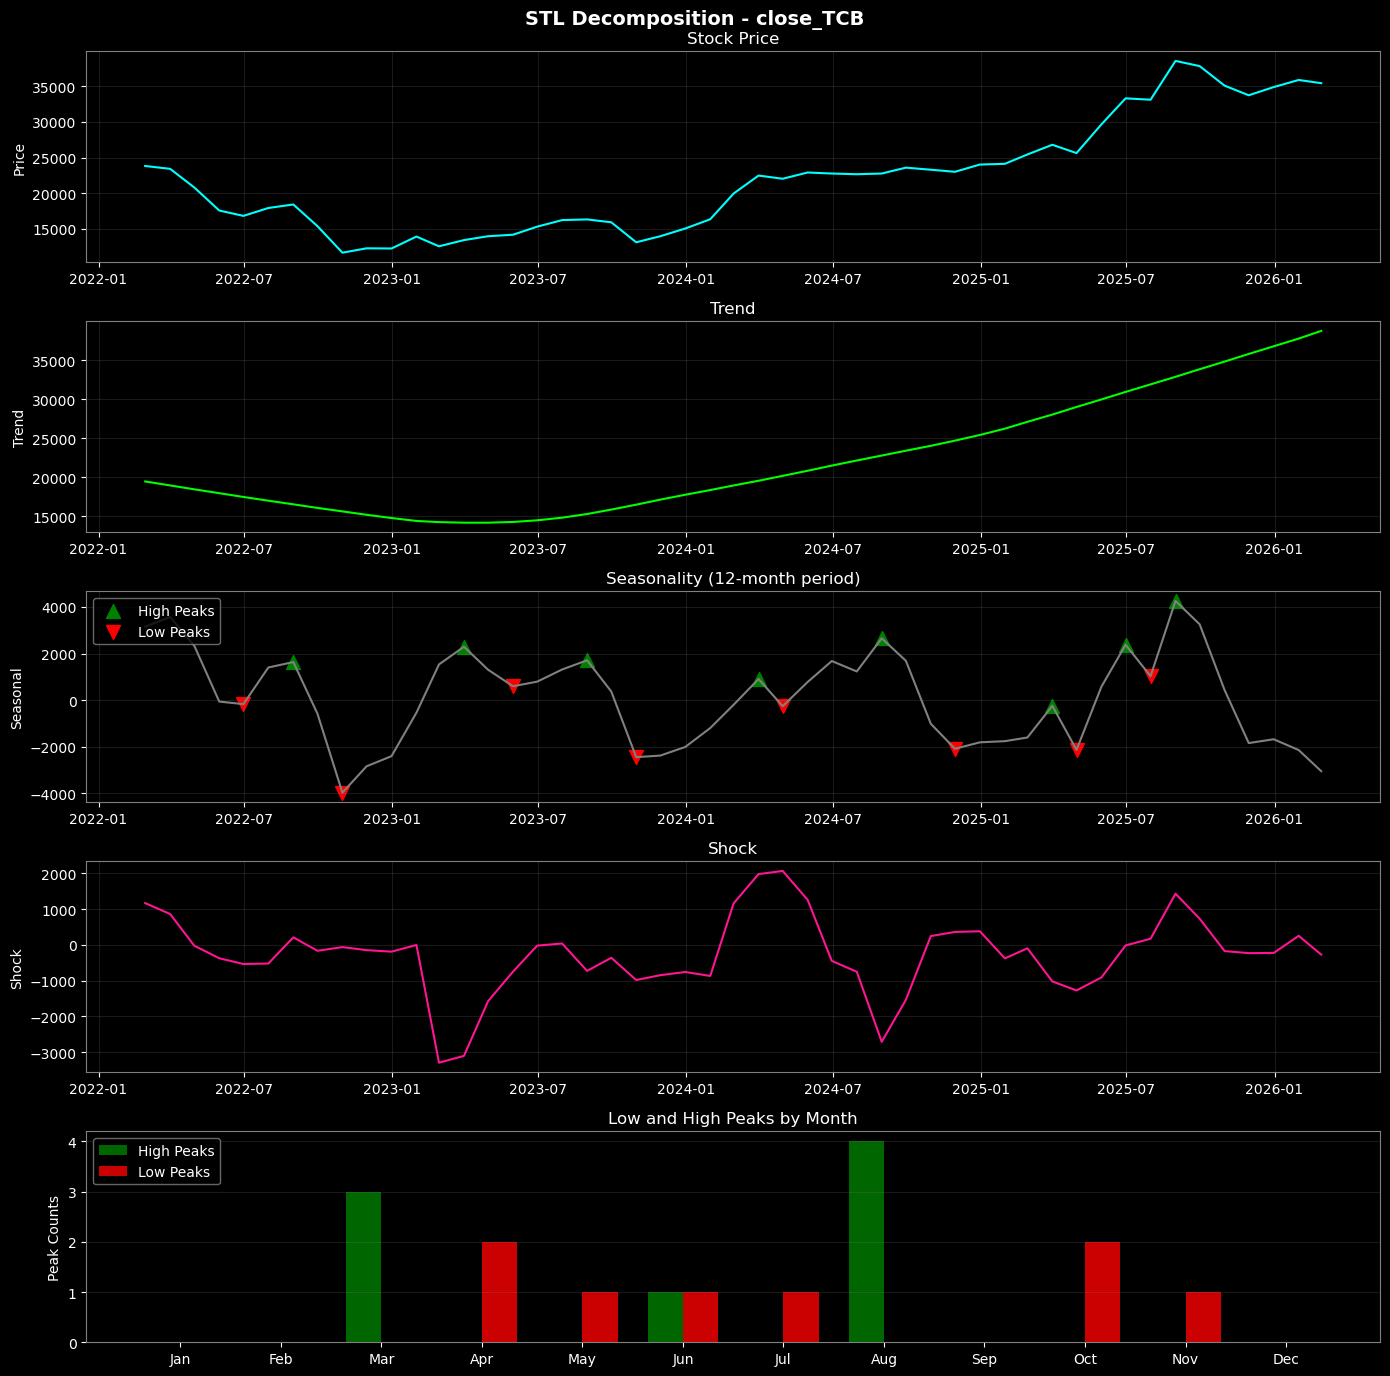

In [687]:
# Seasonality analysis for TCB
analyze_seasonality(df, 'close_TCB')

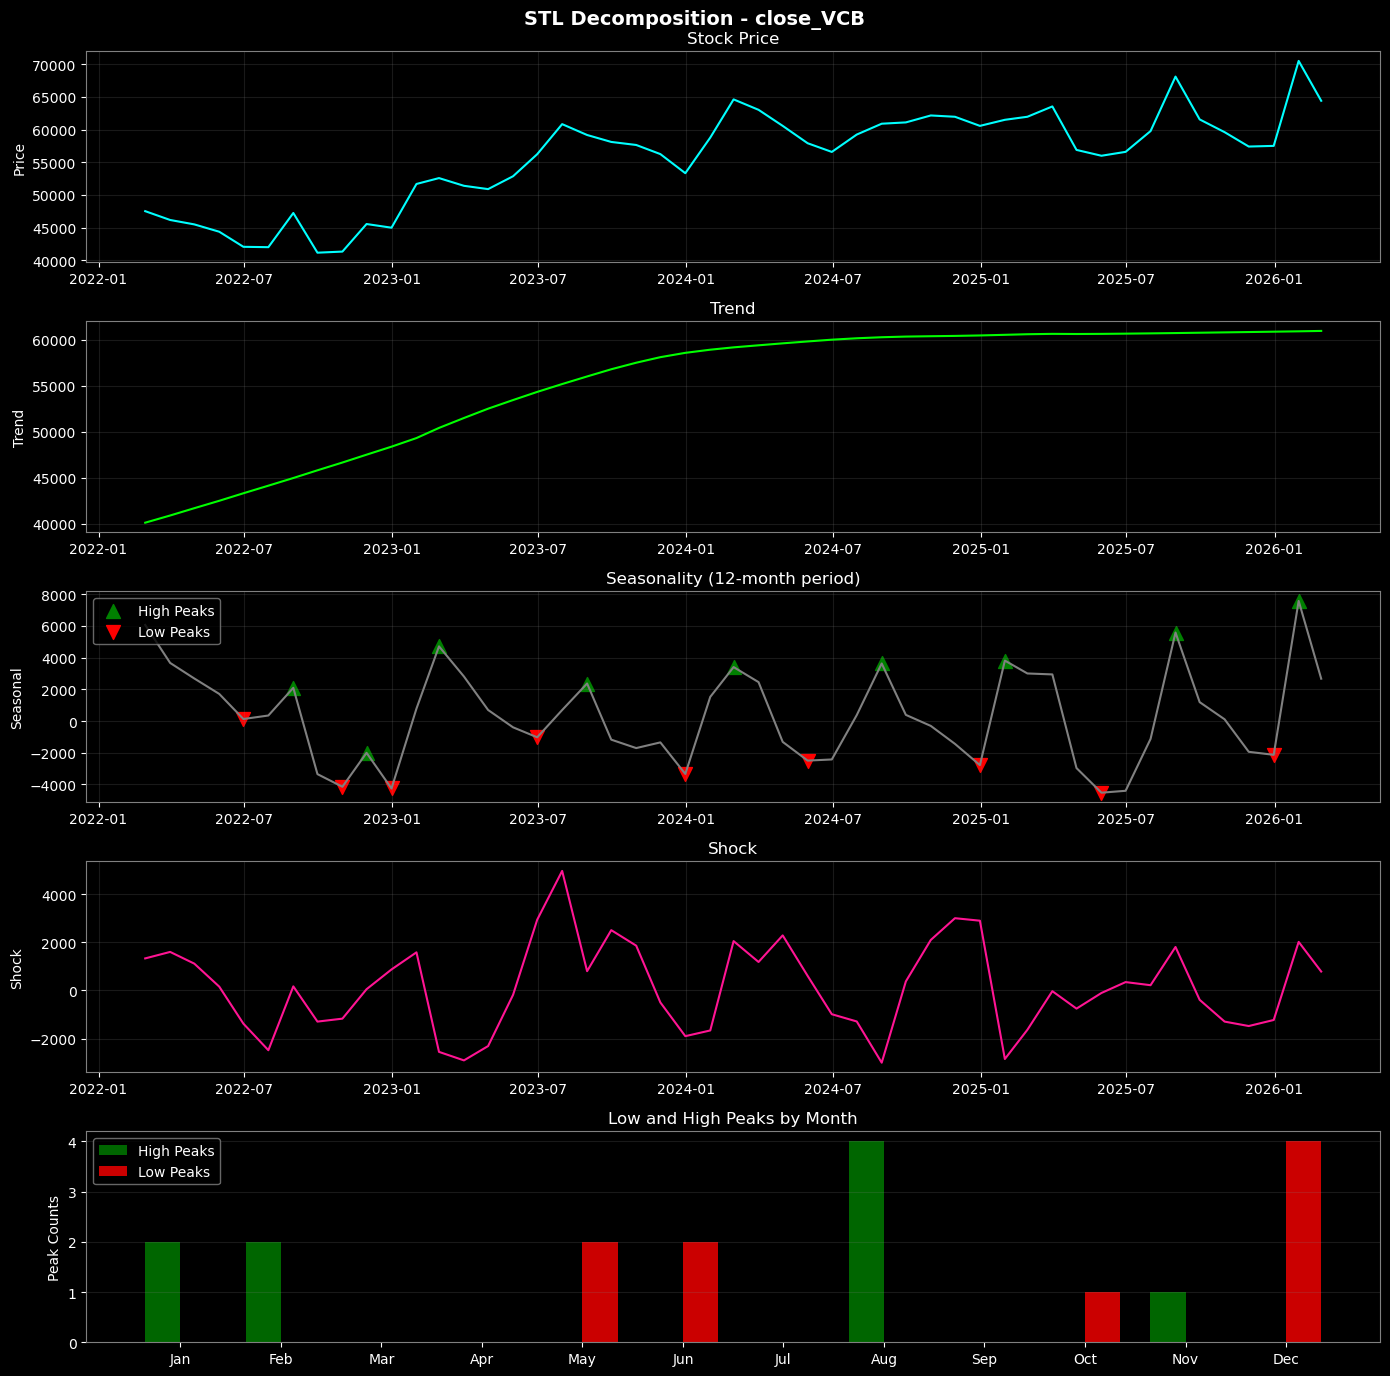

In [688]:
analyze_seasonality(df, 'close_VCB')

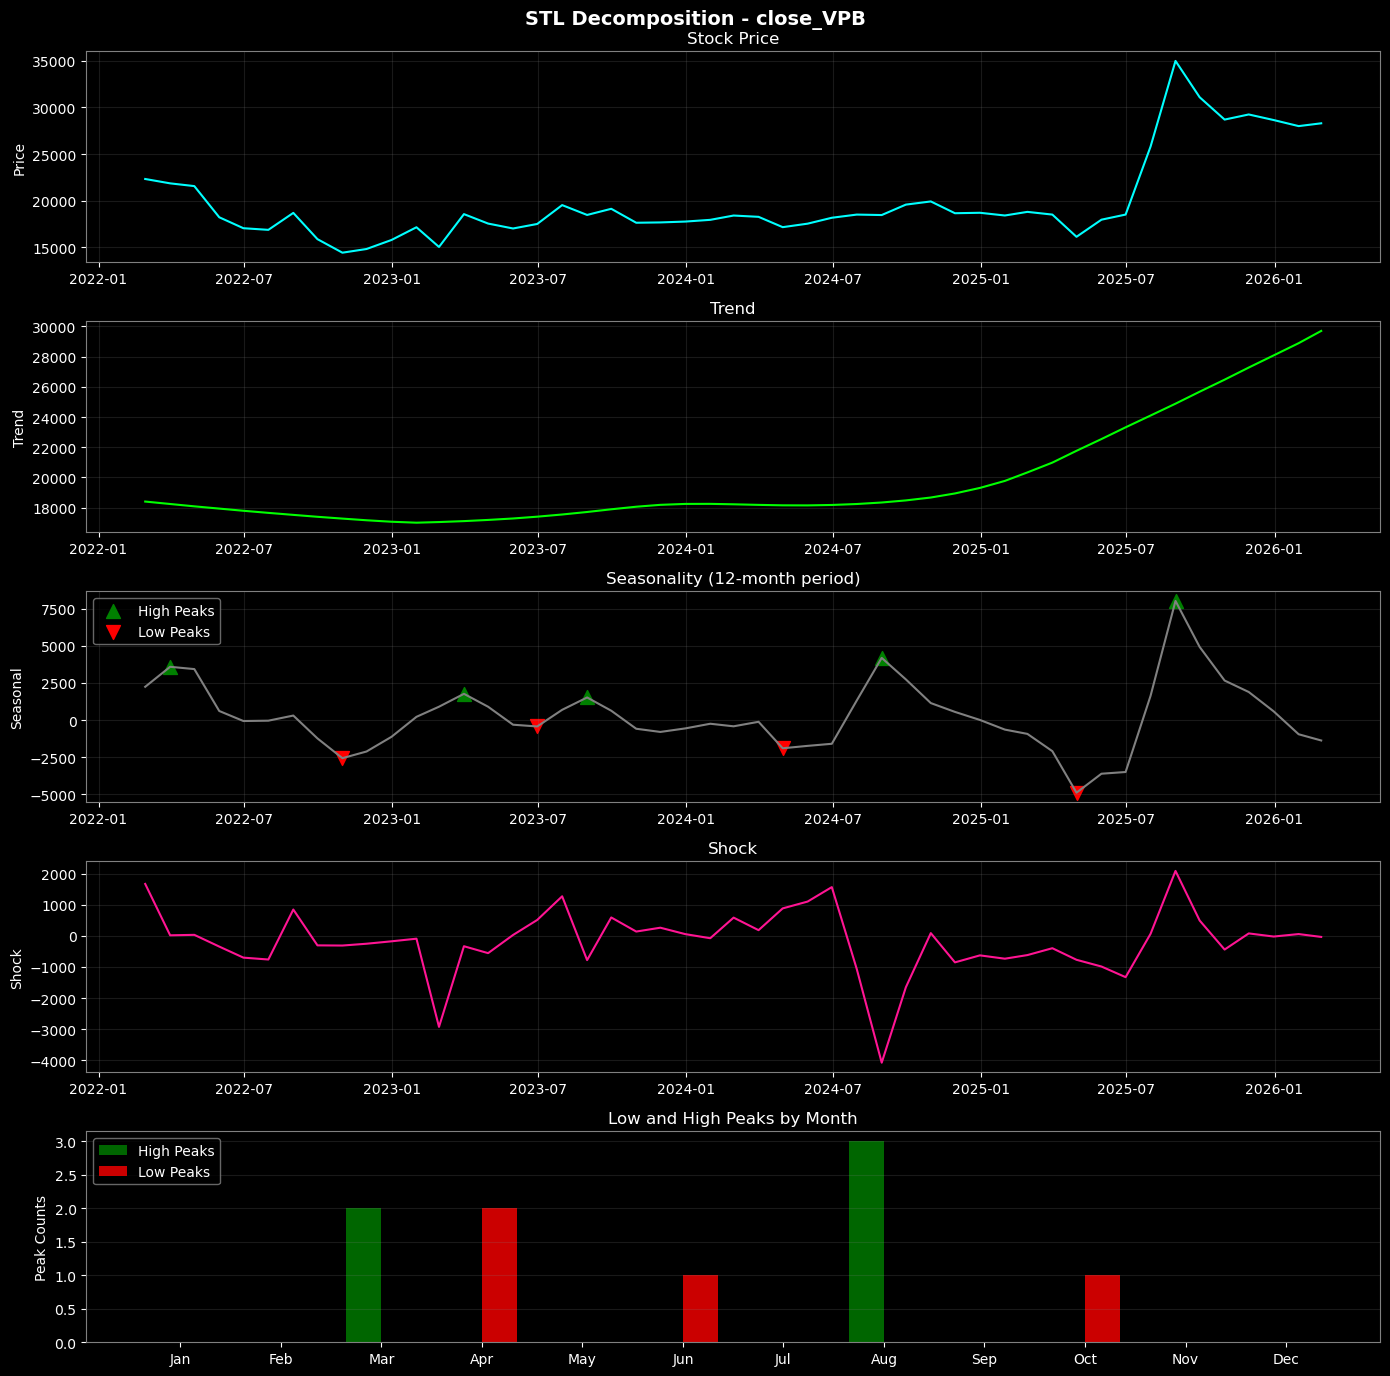

In [689]:
analyze_seasonality(df, 'close_VPB')